In [14]:
import torch
import sys
from pathlib import Path

from mst.models.dino import DinoV2ClassifierSlice
from mst_xai.xai_methods.attention import Attention_MST
from mst.data.datasets.dataset_3d_odelia import ODELIA_Dataset3D
from mst.inference.predictor import load_model
import torch.nn.functional as F

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

run_dir = Path("/home/jovyan/work/MST/runs")

##For New Model
run_folder = Path("DINOv3ViTB")
checkpoint_name = "challenge_mstv3-vit_sch_CB_sub2_best.chkpt"
path_run = run_dir / run_folder / checkpoint_name

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("DinoV2ClassifierSlice", path_run, device)
model.to(device)
model.eval()


Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


DinoV2ClassifierSlice(
  (loss_func): CrossEntropyLoss()
  (auc_roc): ModuleDict(
    (train_): MulticlassAUROC()
    (val_): MulticlassAUROC()
    (test_): MulticlassAUROC()
  )
  (acc): ModuleDict(
    (train_): MulticlassAccuracy()
    (val_): MulticlassAccuracy()
    (test_): MulticlassAccuracy()
  )
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): Layer

In [16]:
ds = ODELIA_Dataset3D(split="test", path_root="/home/jovyan/work/MST/mst/data/datasets/ODELIA_datasets")

sample = ds[22]   # single sample
uid = sample["uid"]
gt = int(sample["target"])

print("UID:", uid, "GT:", gt)


UID: ODELIA_TRICKS_0091_1_right GT: 2


In [17]:
batch = {
    "source": sample["source"].unsqueeze(0).to(device),
    "target": torch.tensor([gt], device=device)
}

In [18]:
print(f"source size = {batch['source'].shape}")
# expected: [1, 1, D, H, W]

source size = torch.Size([1, 1, 32, 224, 224])


### Hook Attention

#### A. Slice Attention

##### Hook Slice Attention

In [19]:
# Need to modify argument in MultiheadAttention (mha) by enabling attention weights output
def enable_attention(module):
    forward_orig = module.forward

    def forward_wrap(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False # to get attn weights for each head # [B, heads, N, N] not [B, N, N]
        return forward_orig(*args, **kwargs)

    module.forward = forward_wrap
    module.forward_orig = forward_orig


def hook_slice_attn(module, input, output):
    # output = (attn_output, attn_weights)
    print("Slice Attention HOOK CALLED")
    slice_attn_maps.append(output[1]) 


# Hook Slice Attention from "Slice fusion" trnasformer
slice_attn_maps = []
slice_hooks = [] 

for h in slice_hooks:
    h.remove()  # remove existing hooks
slice_hooks.clear()  # clear the list

for mod in model.slice_fusion.modules():
    if isinstance(mod, torch.nn.MultiheadAttention):
        mod._forward_hooks.clear()  # clear existing hooks if any
        enable_attention(mod)
        h = mod.register_forward_hook(hook_slice_attn) # register hook to capture attention weights
        slice_hooks.append(h)

##### Run forward

In [20]:
slice_attn_maps.clear()
with torch.no_grad():
    _ = model(batch["source"])

Slice Attention HOOK CALLED


##### Inspect

In [21]:
print(len(slice_attn_maps))  # should be 1 if we hooked only one layer

1


In [22]:
slice_attn = slice_attn_maps[0]  # [1, 12, 33, 33] (B, heads, N, N)
print("Slice Attention shape:", slice_attn.shape)

Slice Attention shape: torch.Size([1, 12, 33, 33])


##### Visualization

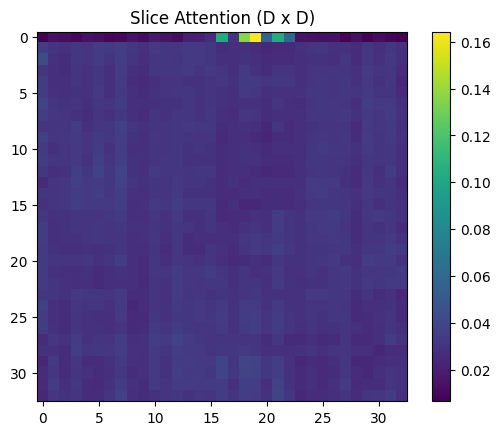

In [23]:
import matplotlib.pyplot as plt
attn_mean = slice_attn.mean(dim=1)  # average over heads
attn_mean_example = attn_mean[0]  # take first -> [N, N] # have only one

plt.imshow(attn_mean_example.cpu())
plt.title("Slice Attention (D x D)")
plt.colorbar()
plt.show()

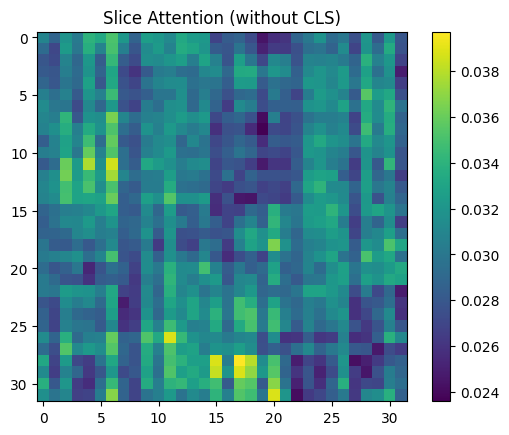

In [24]:
# Remove CLS token        
attn_mean = slice_attn.mean(dim=1)  # average over heads # [1, 33, 33]
# remove CLS (index 0)
attn_slices = attn_mean[:,1:, 1:]   # [32, 32]
attn_slices_example = attn_slices[0]  # take first -> [32, 32]

plt.imshow(attn_slices_example.cpu())
plt.title("Slice Attention (without CLS)")
plt.colorbar()
plt.show()

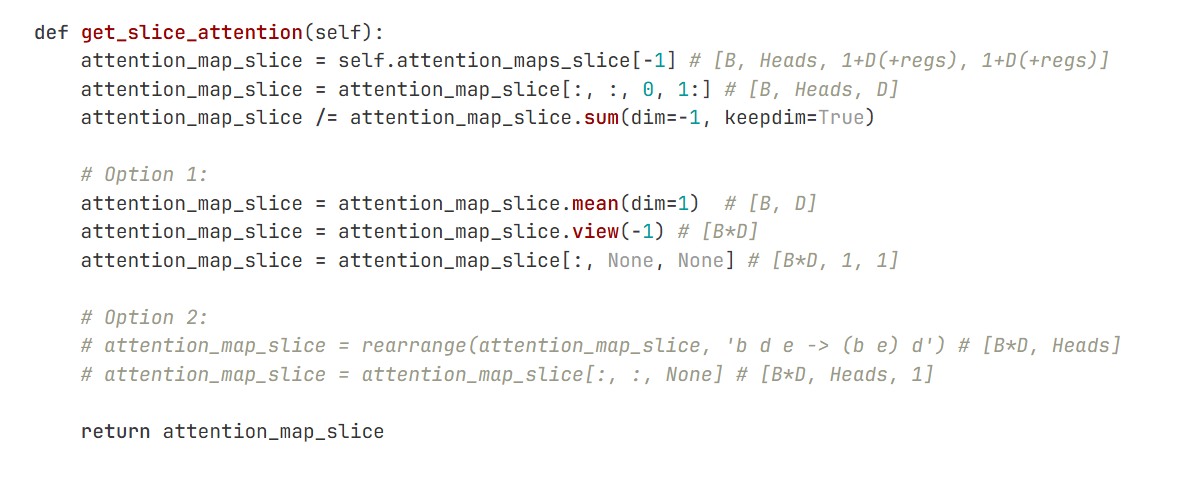
ref: https://gitlab.cc-asp.fraunhofer.de/petersen1/odelia-duke-clf/-/blob/main/mst/models/dino.py?ref_type=heads

CLS to Slices Attention shape: torch.Size([1, 12, 32])
CLS to Slices Attention (averaged over heads) shape: torch.Size([1, 32])
tensor([0.9924], device='cuda:0')


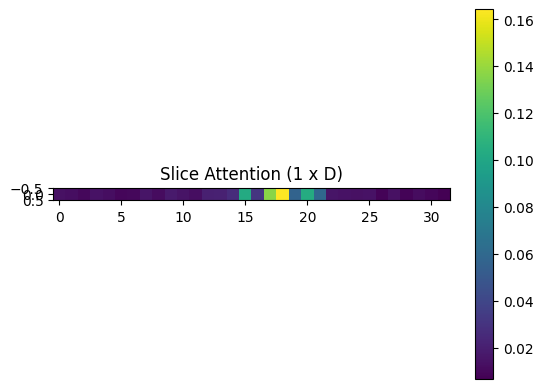

In [25]:
# [1, 12, 33, 33]  [B, heads, N (i), N (j)] # How much token i attnends to token j
# i = query token, j = key token
# Want to extract attention [CLS --> each slice]
# Get i = 0 -> Query = CLS token, j = 1-32 -> slice tokens (all slices)
attn_slices_cls = slice_attn[:, :, 0, 1:]  # [B, heads, N-1] -> CLS token attending to each slice token
print("CLS to Slices Attention shape:", attn_slices_cls.shape)

attn_slices_cls = attn_slices_cls.mean(dim=1) # average over heads -> [B, N-1]
print("CLS to Slices Attention (averaged over heads) shape:", attn_slices_cls.shape)

sums = attn_slices_cls.sum(dim=-1)   # [B, N-1] sum over batch -> [N-1]
print(sums)

plt.imshow(attn_slices_cls.cpu())
plt.title("Slice Attention (1 x D)")
plt.colorbar()
plt.show()



Normalized CLS to Slices Attention shape: torch.Size([1, 32])
tensor([1.], device='cuda:0')


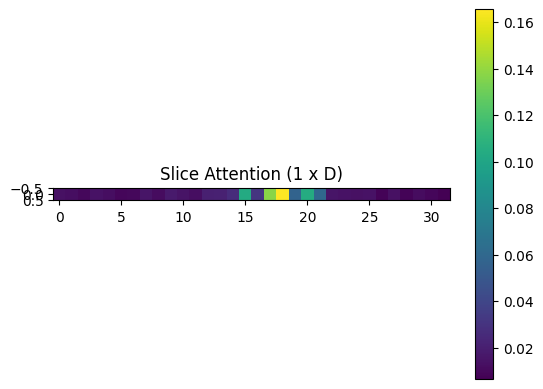

In [26]:

# Normalize Attention so that all slice weights sum to 1
attn_slices_cls /= attn_slices_cls.sum(dim=-1, keepdim=True)  # [B, N-1] normalized
print("Normalized CLS to Slices Attention shape:", attn_slices_cls.shape)
sums = attn_slices_cls.sum(dim=-1)   # [B, N-1] sum over batch -> [N-1]
print(sums)

plt.imshow(attn_slices_cls.cpu())
plt.title("Slice Attention (1 x D)")
plt.colorbar()
plt.show()

#### B. DINOv3 Attention (QKV hook)

##### Hook QKV

In [27]:
for name, mod in model.encoder.named_modules():
    print(name)


patch_embed
patch_embed.proj
patch_embed.norm
rope_embed
blocks
blocks.0
blocks.0.norm1
blocks.0.attn
blocks.0.attn.qkv
blocks.0.attn.attn_drop
blocks.0.attn.proj
blocks.0.attn.proj_drop
blocks.0.ls1
blocks.0.norm2
blocks.0.mlp
blocks.0.mlp.fc1
blocks.0.mlp.act
blocks.0.mlp.fc2
blocks.0.mlp.drop
blocks.0.ls2
blocks.1
blocks.1.norm1
blocks.1.attn
blocks.1.attn.qkv
blocks.1.attn.attn_drop
blocks.1.attn.proj
blocks.1.attn.proj_drop
blocks.1.ls1
blocks.1.norm2
blocks.1.mlp
blocks.1.mlp.fc1
blocks.1.mlp.act
blocks.1.mlp.fc2
blocks.1.mlp.drop
blocks.1.ls2
blocks.2
blocks.2.norm1
blocks.2.attn
blocks.2.attn.qkv
blocks.2.attn.attn_drop
blocks.2.attn.proj
blocks.2.attn.proj_drop
blocks.2.ls1
blocks.2.norm2
blocks.2.mlp
blocks.2.mlp.fc1
blocks.2.mlp.act
blocks.2.mlp.fc2
blocks.2.mlp.drop
blocks.2.ls2
blocks.3
blocks.3.norm1
blocks.3.attn
blocks.3.attn.qkv
blocks.3.attn.attn_drop
blocks.3.attn.proj
blocks.3.attn.proj_drop
blocks.3.ls1
blocks.3.norm2
blocks.3.mlp
blocks.3.mlp.fc1
blocks.3.mlp.act

In [28]:
for name, mod in model.encoder.named_modules():
    if name.endswith("attn"):
        print("ATTN:", name, type(mod))

    if name.endswith("attn.qkv"):
        print("QKV:", name, type(mod))

ATTN: blocks.0.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.0.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>
ATTN: blocks.1.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.1.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>
ATTN: blocks.2.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.2.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>
ATTN: blocks.3.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.3.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>
ATTN: blocks.4.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.4.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>
ATTN: blocks.5.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.5.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>
ATTN: blocks.6.attn <class 'dinov3.layers.attention.SelfAttention'>
QKV: blocks.6.attn.qkv <class 'dinov3.layers.attention.LinearKMaskedBias'>

In [29]:
attn_storage = []
attn_hooks = []
qkv_storage = []
dino_qkv_hooks = []

def hook_attn(module, input, output):
    print("ATTN HOOK CALLED")
    attn_storage.append(output)  # output = (attn_output, attn_weights)

def hook_qkv(module, input, output):
    print("DINOv3 QKV HOOK CALLED")
    qkv_storage.append(output)



for h in dino_qkv_hooks:
    h.remove()  # remove existing hooks
dino_qkv_hooks.clear()  # clear the list

for h in attn_hooks:
    h.remove()  # remove existing hooks
attn_hooks.clear()  # clear the list

for h in slice_hooks:
    h.remove()  # remove existing slice attention hooks
slice_hooks.clear()  # clear the list

# Hook Slice Attention from "Slice fusion" transformer
for mod in model.slice_fusion.modules():
    if isinstance(mod, torch.nn.MultiheadAttention):
        mod._forward_hooks.clear()  # clear existing hooks if any
        enable_attention(mod)
        h = mod.register_forward_hook(hook_slice_attn) # register hook to capture attention weights
        slice_hooks.append(h)
        print(len(mod._forward_hooks))


# Hook at attn level
for name, mod in model.encoder.named_modules():
    if name.endswith("attn"):
        mod._forward_hooks.clear()  # clear existing hooks if any
        h = mod.register_forward_hook(hook_attn) # reuse same hook to capture attn weights at attn level
        attn_hooks.append(h)
        print(name, len(mod._forward_hooks))        


# Hook to capture QKV from DINOv3
for name, mod in model.encoder.named_modules():
    if name.endswith("attn.qkv"):
        mod._forward_hooks.clear()  # clear existing hooks if any
        h = mod.register_forward_hook(hook_qkv)
        dino_qkv_hooks.append(h)
        print(name, len(mod._forward_hooks))



1
blocks.0.attn 1
blocks.1.attn 1
blocks.2.attn 1
blocks.3.attn 1
blocks.4.attn 1
blocks.5.attn 1
blocks.6.attn 1
blocks.7.attn 1
blocks.8.attn 1
blocks.9.attn 1
blocks.10.attn 1
blocks.11.attn 1
blocks.0.attn.qkv 1
blocks.1.attn.qkv 1
blocks.2.attn.qkv 1
blocks.3.attn.qkv 1
blocks.4.attn.qkv 1
blocks.5.attn.qkv 1
blocks.6.attn.qkv 1
blocks.7.attn.qkv 1
blocks.8.attn.qkv 1
blocks.9.attn.qkv 1
blocks.10.attn.qkv 1
blocks.11.attn.qkv 1


but in dino.py the hook .attn, they would like to modify Forward

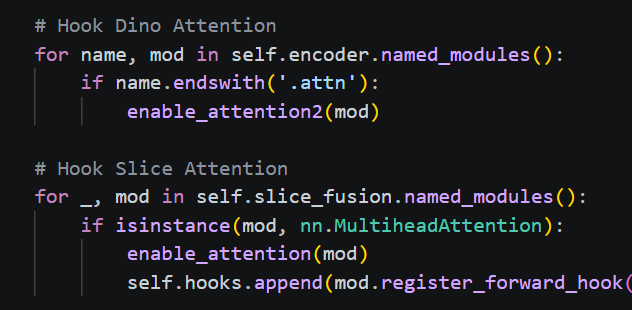

##### Run Forward

In [30]:
slice_attn_maps.clear()
qkv_storage.clear()
attn_storage.clear()
with torch.no_grad():
    _ = model(batch["source"])

DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
DINOv3 QKV HOOK CALLED
ATTN HOOK CALLED
Slice Attention HOOK CALLED


In [31]:
print(len(attn_storage))  # should be 1 if we hooked only one layer
print("Attn output shape:", attn_storage[0].shape)  #

print(len(qkv_storage))  # should be 1 if we hooked only one layer
print("QKV shape:", qkv_storage[0].shape)
print(len(slice_attn_maps))

12
Attn output shape: torch.Size([32, 201, 768])
12
QKV shape: torch.Size([32, 201, 2304])
1


In [32]:
print(qkv_storage[0].shape)

torch.Size([32, 201, 2304])


##### Reconstuction Attention

In [33]:
# Take Last Layer's QKV
qkv = qkv_storage[-1] # [B, N, 3*embed_dim] # [32, 201, 768*3] for ViT-B/16

print("QKV", qkv.shape)

QKV torch.Size([32, 201, 2304])


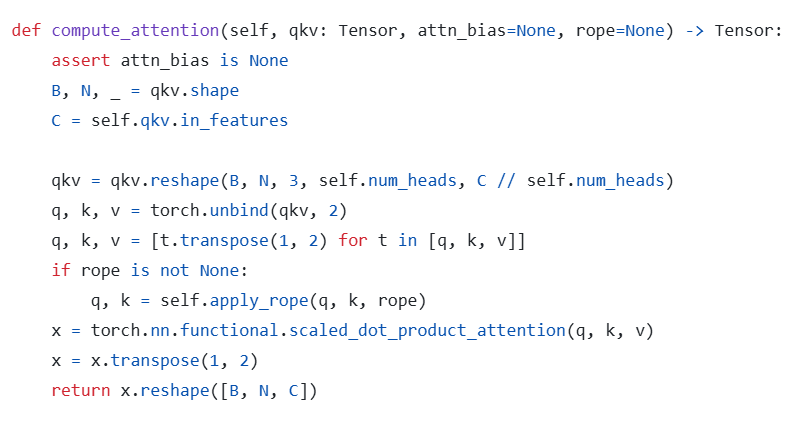

Source : https://github.com/facebookresearch/dinov3/blob/31703e4cbf1ccb7c4a72daa1350405f86754b6d1/dinov3/layers/attention.py

In [34]:
# Final block
qkv = qkv_storage[-1] 

# # remove CLS token + extra tokens
# qkv = qkv[:, 1+4:,]  # [B, N-1, 3*embed_dim]

B, N, _ = qkv.shape

attn_mod = model.encoder.blocks[-1].attn
print("Attn module:", attn_mod)
C = attn_mod.qkv.in_features # should be same as embed_dim = 768 for ViT-B/16

print(f"B: {B}, N: {N}, C: {C}")

num_heads = attn_mod.num_heads
head_dim = C // num_heads

print(f"num_heads: {num_heads}, head_dim: {head_dim}, num_heads*head_dim: {num_heads*head_dim}")

qkv = qkv.reshape(B, N, 3, num_heads, head_dim)
q,k,v = qkv.unbind(dim=2)  # each is [B, N, num_heads, head_dim]
q,k,v = [t.transpose(1,2) for t in [q,k,v]]  # transpose to [B, num_heads, N, head_dim]

rope = model.encoder.rope_embed(H=14, W=14)  # for ViT-B/16 with 224x224 input, H=W=14
q, k = attn_mod.apply_rope(q, k, rope)

Attn module: SelfAttention(
  (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
  (attn_drop): Dropout(p=0.0, inplace=False)
  (proj): Linear(in_features=768, out_features=768, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
)
B: 32, N: 201, C: 768
num_heads: 12, head_dim: 64, num_heads*head_dim: 768


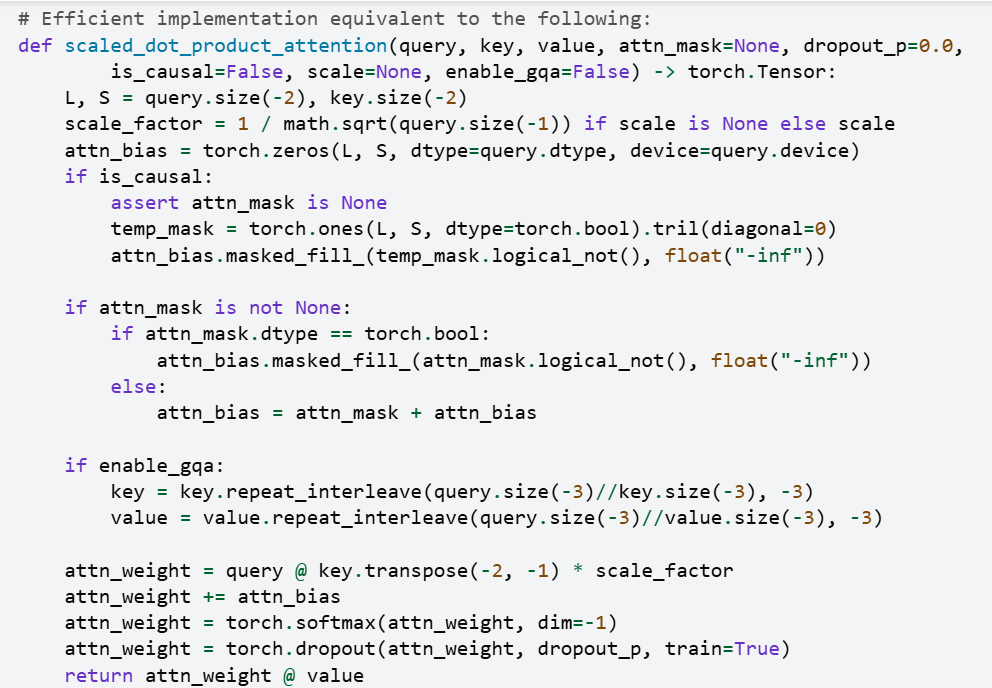

ref: https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html

In [35]:
print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([32, 12, 201, 64])
torch.Size([32, 12, 201, 64])
torch.Size([32, 12, 201, 64])


In [36]:
# Compute Attention Manually
# scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
# scale_factor = 1 / √(dimension of each head)
scale_factor = q.shape[-1] ** -0.5 # shape [-1] = head dimension

attn = q @ k.transpose(-2, -1) * scale_factor  # q = [B, num_heads, N, head_dim], k = [B, num_heads, N, head_dim] -> [B, num_heads, N, N]
print("Raw Attention shape:", attn.shape)
# [B, num_heads, N(i), N(j)] # How much token i attends to token j # sum over j for each i should be 1 after softmax
attn = torch.softmax(attn, dim=-1) 
print(attn.shape)

Raw Attention shape: torch.Size([32, 12, 201, 201])
torch.Size([32, 12, 201, 201])


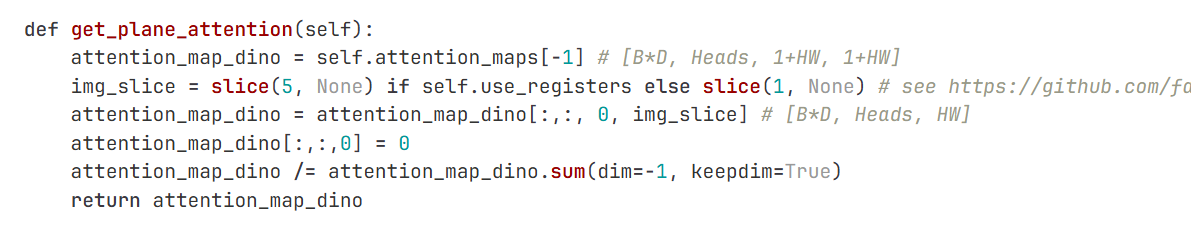

ref:https://gitlab.cc-asp.fraunhofer.de/petersen1/odelia-duke-clf/-/blob/main/mst/models/dino.py?ref_type=heads

In [37]:
# spatial_attn_mean = attn.mean(dim=1)  # average over heads -> [B, N, N]
# print("Spatial Attention (averaged over heads) shape:", spatial_attn_mean.shape)

spatial_attn = attn[:,:, 0, 1+4:] # CLS token attend to all tokens (remove extra tokens if needed) # [B, num_heads, 1 , N-1-4]
print("CLS to Tokens Attention shape:", spatial_attn.shape)

# ?????????????
# Set First token attention to 0
spatial_attn[:,:,0] = 0

#normalize attention so that all slice weights sum to 1
spatial_attn /= spatial_attn.sum(dim=-1, keepdim=True)  # [B, num_heads, 1 , N-1-4] normalized
print("Normalized CLS to Tokens Attention shape:", spatial_attn.shape)

CLS to Tokens Attention shape: torch.Size([32, 12, 196])
Normalized CLS to Tokens Attention shape: torch.Size([32, 12, 196])


CLS to Tokens Attention (averaged over heads) shape: torch.Size([32, 196])


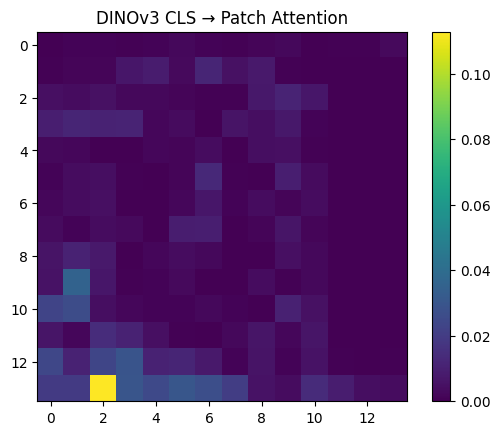

In [38]:
spatial_attn = spatial_attn.mean(dim=1)  # average over heads -> [B, 1, N-1-4]
print("CLS to Tokens Attention (averaged over heads) shape:", spatial_attn.shape)

plt.imshow(spatial_attn[0].reshape(14, 14).cpu())
plt.title("DINOv3 CLS → Patch Attention")
plt.colorbar()
plt.show()

### Calculate Slight-weighted Attention

In [39]:
B, C, D, H, W = batch["source"].shape
print(batch["source"].shape)
print(f"Batch dimensions B: {B}, C: {C}, D: {D}, H: {H}, W: {W}")
# Get patch size from the model
patch_size = model.encoder.patch_embed.patch_size
print(type(patch_size), patch_size)

# get patch size (square patches)
patch_size = patch_size[0]
print(f"Patch size: {patch_size}")

torch.Size([1, 1, 32, 224, 224])
Batch dimensions B: 1, C: 1, D: 32, H: 224, W: 224
<class 'tuple'> (16, 16)
Patch size: 16


In [40]:
attn_slices_cls.shape

torch.Size([1, 32])

In [41]:
spatial_attn.shape

torch.Size([32, 196])

In [42]:
D = spatial_attn.shape[0]  # number of slices

saliency_slice = []

for d in range(D):
    attn_slice = spatial_attn[d]

    saliency_2d = attn_slice.reshape(14, 14)  # reshape to spatial dimensions
    saliency_slice.append(saliency_2d)

saliency_volume = torch.stack(saliency_slice)
print("Saliency volume shape:", saliency_volume.shape)



Saliency volume shape: torch.Size([32, 14, 14])


In [43]:
slice_weights = attn_slices_cls.squeeze(0).view(-1, 1, 1)   # [32,1,1]

print("Slice weights shape:", slice_weights.shape)
saliency = saliency_volume * slice_weights  # [D, H, W]
print("Saliency shape:", saliency.shape)

Slice weights shape: torch.Size([32, 1, 1])
Saliency shape: torch.Size([32, 14, 14])


In [44]:
saliency = saliency.unsqueeze(0)  # [B=1, D, 14, 14]
print("Saliency after unsqueeze shape:", saliency.shape)

Saliency after unsqueeze shape: torch.Size([1, 32, 14, 14])


In [45]:
saliency = F.interpolate(
    saliency.unsqueeze(1),     # [1,1,D,14,14]
    size=(D, 224, 224),
    mode='trilinear',
    align_corners=False
).squeeze(1)   # [1,D,224,224]

In [46]:
saliency = saliency - saliency.min()
saliency = saliency / (saliency.max() - saliency.min() + 1e-8)

In [47]:
saliency = saliency.squeeze(0)  # [D, 224, 224]
saliency.shape

torch.Size([32, 224, 224])

In [48]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def overlay_heatmap(image, saliency, alpha=0.5):
    
    image_uint8 = np.uint8(255 * image)
    heatmap_uint8 = np.uint8(255 * saliency)

    heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        heatmap,
        alpha,
        np.stack([image_uint8]*3, axis=-1),
        1-alpha,
        0
    )

    return overlay

def concat_input_overlay(input_2d, overlay_rgb):
    """
    input_2d: (H, W) normalized [0,1]
    overlay_rgb: (H, W, 3) uint8 or float [0,255]
    """
    # convert input to RGB
    input_uint8 = np.uint8(255 * input_2d)
    input_rgb = np.stack([input_uint8]*3, axis=-1)

    # ensure same dtype
    if overlay_rgb.dtype != np.uint8:
        overlay_rgb = np.uint8(overlay_rgb)

    # concatenate horizontally
    combined = np.concatenate([input_rgb, overlay_rgb], axis=1)
    return combined

min_volume :=0.0, max_volume :=1.0
min_saliency :=0.0, max_saliency :=0.9999991655349731


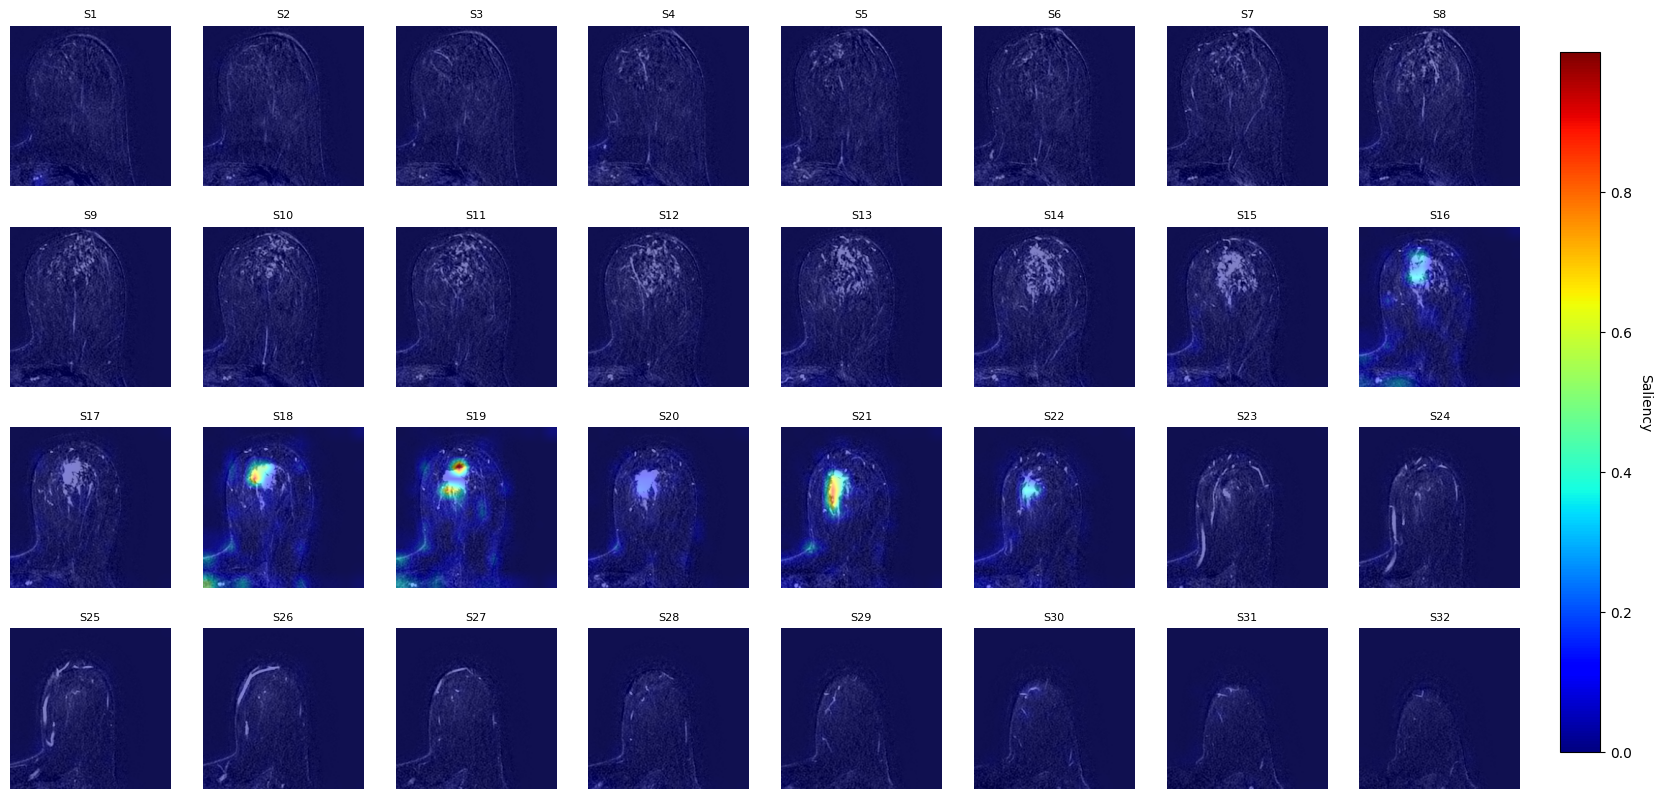

In [49]:
overlays = []
num_slices = batch["source"].shape[2]
volume = batch["source"].squeeze(0).squeeze(0).cpu().numpy()  # (D, H, W)
volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)  # Normalize to [0,1]
print(f"min_volume :={volume.min()}, max_volume :={volume.max()}")
saliency = saliency.detach().cpu().numpy()  # (D, H, W)
print (f"min_saliency :={saliency.min()}, max_saliency :={saliency.max()}")
for i in range(num_slices):
    overlays.append(
        overlay_heatmap(volume[i], saliency[i])
    )

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(overlays[i])
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")

#fig.suptitle(f"{uid} | {class_name} | {method_name}", fontsize=14)

# overlay_path = os.path.join(
#     class_save_root,
#     f"{uid}_{class_name}_{method_name}_overlay.png"
# )

fig.subplots_adjust(right=0.88)  # leave space on right
# -------------------------
# Add colorbar axis manually
# -------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=saliency.min(), vmax=saliency.max())
sm = cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# Create dedicated axis for colorbar
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Saliency", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.savefig(overlay_path, dpi=150)
plt.show()
plt.close(fig)